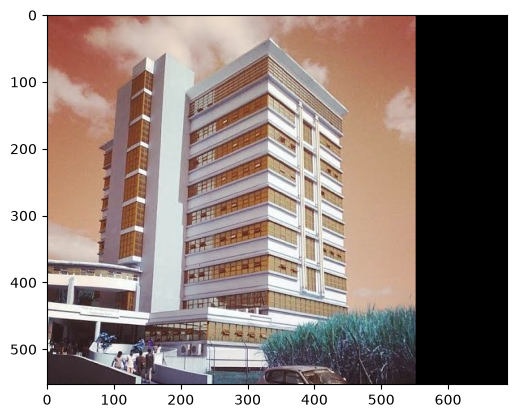

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import randrange

#Input image and then convert from RGB to Gray
# Resized Left Image e.g. 600 x 448
image1 = cv2.imread('TowerLeft.jpg')
image1_gray = cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
# Resized Right Image e.g. 600 x 448
image2 = cv2.imread('TowerRight.jpg')
image2_gray = cv2.cvtColor(image2,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

#This step computes the sift keypoints and descriptors
keypoint1, descriptor1 = sift.detectAndCompute(image1_gray,None)
keypoint2, descriptor2 = sift.detectAndCompute(image2_gray,None)
cv2.imshow('orig_img_lft_keypnts',cv2.drawKeypoints(image1,keypoint1,None))
cv2.imwrite('orig_img_lft_keypnts.jpg',cv2.drawKeypoints(image1,keypoint1,None))
cv2.imshow('orig_img_rght_keypnts',cv2.drawKeypoints(image2,keypoint2,None))
cv2.imwrite('orig_img_rght_keypnts.jpg',cv2.drawKeypoints(image1,keypoint1,None))

#The FLANN method matches the features which are more similar. 
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=1000)
flann = cv2.FlannBasedMatcher(index_params,search_params)
matched_features = flann.knnMatch(descriptor1,descriptor2,k=2)

#This step filters through all the matches to obtain the best ones. 
ratio_pass = []
for f in matched_features:
	if f[0].distance < 0.25*f[1].distance:
		ratio_pass.append(f)
		matched_features = np.asarray(ratio_pass)

#This step will run RANSAC to estimate homography and performs image alignment.
if len(matched_features[:,0]) >= 2:
	init = np.float32([ keypoint1[f.queryIdx].pt for f in matched_features[:,0] ]).reshape(-1,1,2)
	goal = np.float32([ keypoint2[f.trainIdx].pt for f in matched_features[:,0] ]).reshape(-1,1,2)
	H, _ = cv2.findHomography(init, goal, cv2.RANSAC, 9.0)
else:
	print("Not able to find enough kpnts")

#This step performs the wrap to align for stitching.
final = cv2.warpPerspective(image1,H,(image2.shape[1] + image1.shape[1], image2.shape[0]))
plt.show()
plt.figure()
final[0:image2.shape[0], 0:image2.shape[1]] = image2
cv2.imwrite('Stitched_Image.jpg',final)
plt.imshow(final)
plt.show()